In [399]:
# グラフ描画用

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [400]:
import math
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0                #backwardで使う
        self._prev = set(_children)  #backwardで使う
        self._op = _op               #draw_dotで使う
        self.label = label           #draw_dotで使う
        def _backward():
            return None
        self._backward = _backward

    def __repr__(self): # インスタンスを見栄えの良い形で表示する
        return f"Value({self.label}, data = {self.data}, grad = {self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # otherがValueか確認して違かったらValueでラップ
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            #2回以上呼ばれたときに上書きしないために+=にする　例) b=a+a の勾配が2。だけど+=にしないと1になる。
            self.grad += out.grad
            other.grad += out.grad

        #関数を変数に代入する。紛らわしいけど次にout._backward()をしたら実行される
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # otherがValueか確認して違かったらValueでラップ
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            #2回以上呼ばれたときに上書きしないために+=にする　例) b=a*a の勾配が2a。だけど+=にしないと2になる。
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        #関数を変数に代入する。紛らわしいけど次にout._backward()をしたら実行される
        out._backward = _backward

        return out

    def __rmul__(self, other): #__mul__が無理だったら自動実行される関数
        return self.__mul__(other)

    def __sub__(self, other):
        return self + (-other)

    def __pow__(self, other):
        other = other if isinstance(other, (int,float)) else float(other)
        out = Value(self.data ** other, (self,), f"**{other}")

        def _backward():
            #2回以上呼ばれたときに上書きしないために+=にする
            self.grad += (other * self.data ** (other-1)) * out.grad

        #関数を変数に代入する。紛らわしいけど次にout._backward()をしたら実行される
        out._backward = _backward

        return out

    def __neg__(self):
        return self * -1

    def __truediv__(self, other):
        return self * other**-1

    def exp(self):
        out = Value(math.exp(self.data), (self, ), "exp()")

        def _backward():
            #2回以上呼ばれたときに上書きしないために+=にする
            self.grad += out.data * out.grad

        #関数を変数に代入する。紛らわしいけど次にout._backward()をしたら実行される
        out._backward = _backward
        
        return out

    def tanh_a(self):

        out = Value(math.tanh(self.data), (self,), "tanh")

        def _backward():
            #2回以上呼ばれたときに上書きしないために+=にする
            self.grad += (1 - out.data**2) * out.grad

        #関数を変数に代入する。紛らわしいけど次にout._backward()をしたら実行される
        out._backward = _backward
        
        return out

    def tanh(self): #既に定義された+,-,/,exp()を使うため、実行しただけで他の関数が勝手にbackwardまで準備してくれる。
        return ((2*self).exp()-1) / ((2*self).exp()+1)

    def relu(self):
        out = Value(max(self.data, 0), (self,), "relu")

        def _backward():
            #2回以上呼ばれたときに上書きしないために+=にする
            self.grad += (1 if self.data > 0 else 0) * out.grad

        #関数を変数に代入する。紛らわしいけど次にout._backward()をしたら実行される
        out._backward = _backward
        
        return out


    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            v._backward()

In [401]:
#勾配チェッカー
def grad_checker(f, xs, h=1e-5, tol=1e-7):
    vs = [Value(x) for x in xs] #通常のx
    out = f(vs)
    out.backward()
    ok = True

    for i in range(len(xs)): #x+h,x-hの時
        xplus = list(xs); xplus[i] += h
        xminus = list(xs); xminus[i] -= h
        fplus = f([Value(x) for x in xplus]).data
        fminus = f([Value(x) for x in xminus]).data
        num = (fplus-fminus) / (2*h)
        ana = vs[i].grad
        if abs(num-ana)/max(abs(num),abs(ana),1) > tol:
            ok = False
            print(f"NG i={i}: {ana}, {num}")
    return ok

assert grad_checker(lambda v: v[0].relu(), [-5.0])      # 負側。grad=0 になるか
assert grad_checker(lambda v: v[0].tanh(), [0.7])       # 合成版
assert grad_checker(lambda v: v[0].tanh_a(), [0.7])     # 単一ノード版。上と一致するか
assert grad_checker(lambda v: v[0]**3, [2.0])
assert grad_checker(lambda v: (v[0]/v[1]), [3.0, 2.0])

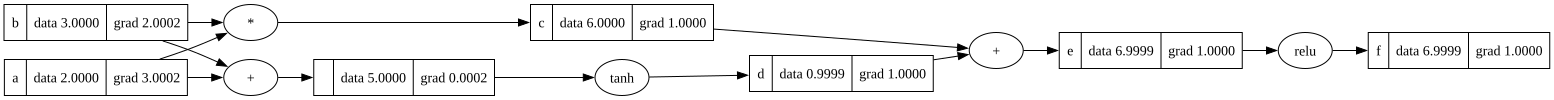

In [402]:
a = Value(2.0, label="a")
b = Value(3.0, label="b")
c = a * b
c.label = "c"
d = (a + b).tanh_a()
d.label = "d"
e = c + d
e.label = "e"
f = e.relu()
f.label = "f"
f.backward()
draw_dot(f)

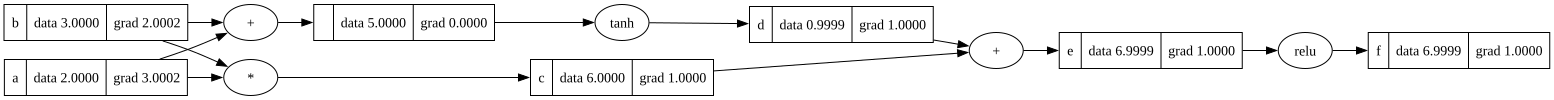

In [403]:
a = Value(2.0, label="a")
b = Value(3.0, label="b")
c = a * b
c.label = "c"
d = (a + b).tanh_a()
d.label = "d"
e = c + d
e.label = "e"
f = e.relu()
f.label = "f"
f.grad = 1
e.grad = 1*f.grad
d.grad = 1*e.grad
c.grad = 1*e.grad
# (a+b).grad = 1-tanh(a+b)**2 * d.grad
b.grad = (1 * (1-math.tanh((a+b).data)**2 * d.grad)) + (a.data * c.grad)
a.grad = (1 * (1-math.tanh((a+b).data)**2 * d.grad)) + (b.data * c.grad)
draw_dot(f)

In [404]:
# MLP構築

import random
class Neuron:
    def __init__(self,nin): # ランダムな値で初期値の重みをもったニューロンを作る。bは一つ。
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x): # Nuron([3,4,1])のように呼ばれたら、x=[3,4,1]とw=重みとb=バイアスの計算結果を返す。wi*x:i+b
        out = sum([wi*xi for wi,xi in zip(self.w,x)], self.b)
        return out.tanh() # 活性化関数を入れないと線形のままなため何層重ねても一層と同じ深さにしかならない。

    def parameters(self): # パラメータ一覧を返す関数。bはただの数値だから[]でリストにしてからwと結合して返す。
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        return [neuron(x) for neuron in self.neurons]

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        ns = [nin] + nouts
        self.layers = [Layer(ns[i], ns[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [405]:
# モデル定義
n = MLP(3, [4, 4, 1])
# 学習に使うデータ
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
# backwardループで改善
for i in range(100):
    # forward
    # n(x)は最終層の出力がリスト形式で返ってくるから、n(x)[0]でリストから出す必要がある。
    pre_ys = [n(x)[0] for x in xs] # あとでbackward()したいからpre_ys.はValueクラスのまま
    # loss
    loss = sum((pre_y - y)**2 for pre_y, y in zip(pre_ys, ys)) # Valueクラス(pre_ys)とfloat型(ys)の計算
    # zero_grad
    for i in n.parameters():
        i.grad = 0
    # backward
    loss.backward() #lossもValueクラスのままだから.backward()が使える
    # update
    for i in n.parameters():
        i.data -= 0.05 *i.grad

    print(loss)

Value(, data = 4.503185864738491, grad = 1)
Value(, data = 3.542444935149357, grad = 1)
Value(, data = 2.4520104001463823, grad = 1)
Value(, data = 1.2138076844236314, grad = 1)
Value(, data = 0.601184718531696, grad = 1)
Value(, data = 0.3649727869907578, grad = 1)
Value(, data = 0.25207777389347585, grad = 1)
Value(, data = 0.18863841020190508, grad = 1)
Value(, data = 0.14904348303235893, grad = 1)
Value(, data = 0.12237760065102955, grad = 1)
Value(, data = 0.10336773491335613, grad = 1)
Value(, data = 0.08921143969307298, grad = 1)
Value(, data = 0.07830227567971418, grad = 1)
Value(, data = 0.06966148116510486, grad = 1)
Value(, data = 0.06266223870365724, grad = 1)
Value(, data = 0.05688619828748036, grad = 1)
Value(, data = 0.05204430387502221, grad = 1)
Value(, data = 0.04793087594331466, grad = 1)
Value(, data = 0.04439582483620673, grad = 1)
Value(, data = 0.04132720815400029, grad = 1)
Value(, data = 0.038639926928433016, grad = 1)
Value(, data = 0.03626819266939351, grad =

# 勾配チェッカ

In [407]:
# モデル定義
n = MLP(3, [4, 4, 1])
# 学習に使うデータ
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

h = 1e-5

In [408]:
p = n.parameters()[40]
# zero_grad
for i in n.parameters():
    i.grad = 0
# loss
def compute_loss():
    pre_ys = [n(x)[0] for x in xs]
    return sum((pre_y - y)**2 for pre_y, y in zip(pre_ys, ys))
loss = compute_loss()
# backward
loss.backward()
print(p.grad)
p.data += h
loss_plus = compute_loss()

p.data -= 2*h
loss_minus = compute_loss()

grad = (loss_plus - loss_minus) / (2*h)

print(grad.data)


-2.68620452017886
-2.686204520152557
